In [142]:
%run import_libs.py

In [ ]:
root = 'D:/yueying/gazeObject_YueyingDong/results/'

In [18]:
precue_T = np.array([0.5,1.5,2.5,3,6]) - 0.5
retrocue_T = np.array([0.5,1.5,2,2.5,3,6]) - 0.5

In [25]:
task = 'precue'  # 'retrocue' or 'precue'
if task == 'retrocue':
    gazePath = glob.glob(f'{root}/data/gazeClean/*.csv')[-1:]
    psyPath = [glob.glob(f'{root}/data/psychopy/*36*.csv')[0]]
    time = retrocue_T
else:
    gazePath = glob.glob(f'{root}/data/gazeClean/*.csv')[:-1]
    psyPath = [glob.glob(f'{root}/data/psychopy/*31*.csv')[0],
               glob.glob(f'{root}/data/psychopy/*35*.csv')[0]]
    time = precue_T

In [26]:
trlInfo = pd.DataFrame()
gazeClean = pd.DataFrame()

if input('ran processing code? y/n') == 'y':

    # read only every 10th gaze-sample column (plus id cols) directly,
    # instead of loading all ~6000 columns per file and slicing afterwards
    keepCols = [0, 1] + list(range(2, 6002, 10))
    gazeClean = pd.concat(
        [pd.read_csv(i).iloc[:, keepCols] for i in gazePath],
        axis=0, ignore_index=True,
    )

    trlInfoList = []
    for i in psyPath:
        df = pd.read_csv(i)[['participant', 'TRIALID', 'stimImage', 'trlType']]
        df['stimImage'] = df['stimImage'].str.split('/').str[-1]
        trlInfoList.append(df)
    trlInfo = pd.concat(trlInfoList, axis=0, ignore_index=True)

    gazeClean = gazeClean.merge(trlInfo, how='left', on='TRIALID')
else:
    print('no processing required. Ran following cells for result visualizations')

# Figure 4A

In [27]:
baseImg = 'bear_08s.jpg'
targetImg1 = 'hedgehog_13s.jpg'
targetImg2 = 'headphones_06s.jpg'

In [28]:
dataN = 550 # 5500ms = 5.5s, 550 gaze samples

In [29]:
baseTrl = trlInfo[trlInfo.stimImage == baseImg].TRIALID.values
targetTrl1 = trlInfo[trlInfo.stimImage == targetImg1].TRIALID.values
targetTrl2 = trlInfo[trlInfo.stimImage == targetImg2].TRIALID.values

# get the gaze data for these images, averaged across trials, for each axis (x and y)
baseTrlGaze = gazeClean[gazeClean.TRIALID.isin(baseTrl)].groupby('axis').mean(numeric_only = True).iloc[:,50:-1].values
targetTrl1Gaze = gazeClean[gazeClean.TRIALID.isin(targetTrl1)].groupby('axis').mean(numeric_only = True).iloc[:,50:-1].values
targetTrl2Gaze = gazeClean[gazeClean.TRIALID.isin(targetTrl2)].groupby('axis').mean(numeric_only = True).iloc[:,50:-1].values


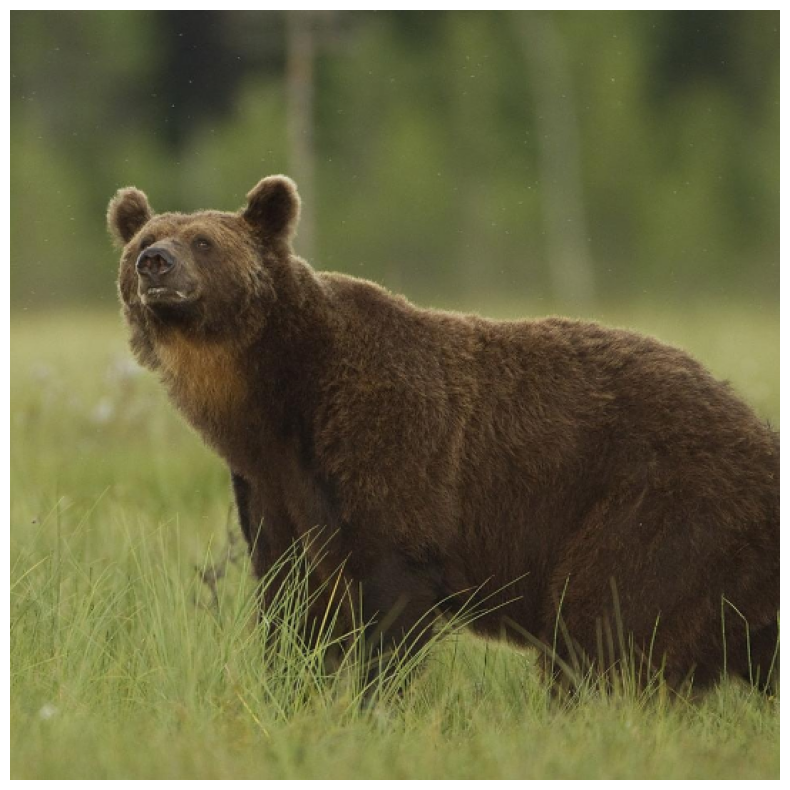

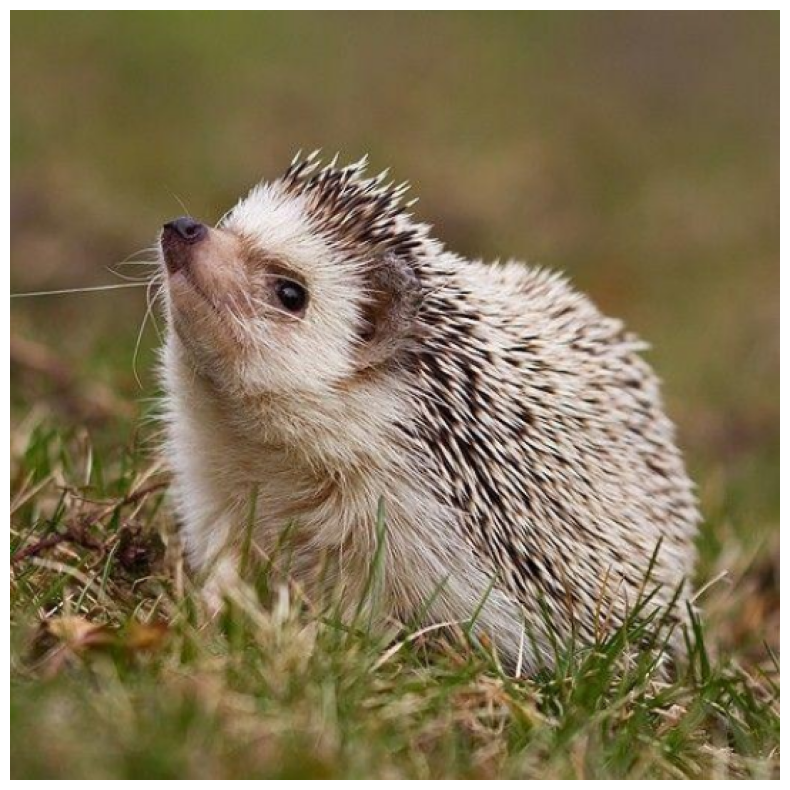

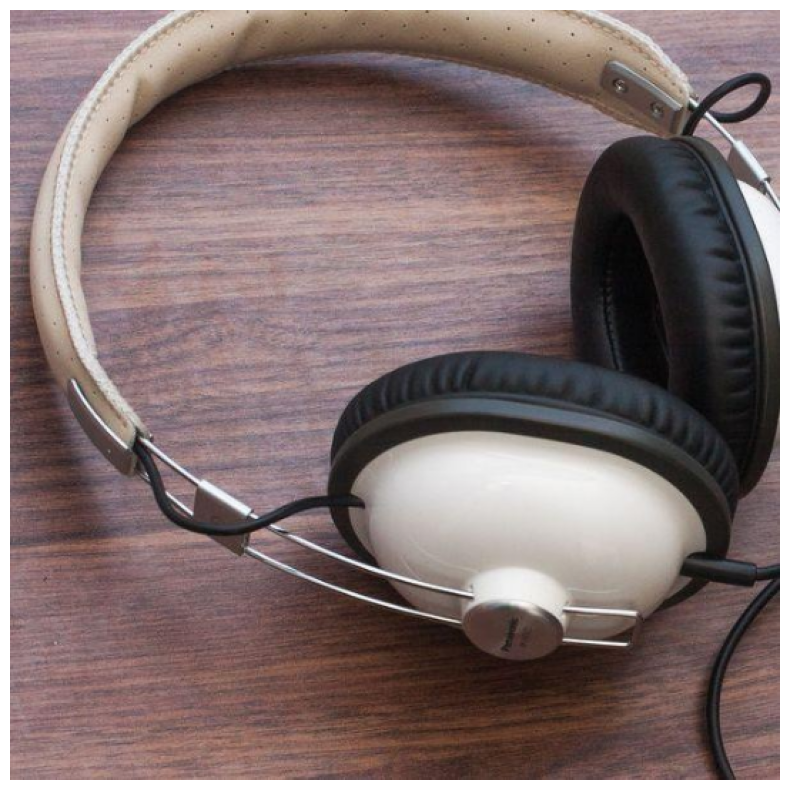

In [33]:
def show_expimage(filename, size=(540, 540)):
    img = cv2.imread('../expImages40/' + filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(cv2.resize(img, size), alpha=1)
    plt.axis('off')
    plt.show()

fs(10, 10)

for img in (baseImg, targetImg1, targetImg2):
    show_expimage(img)


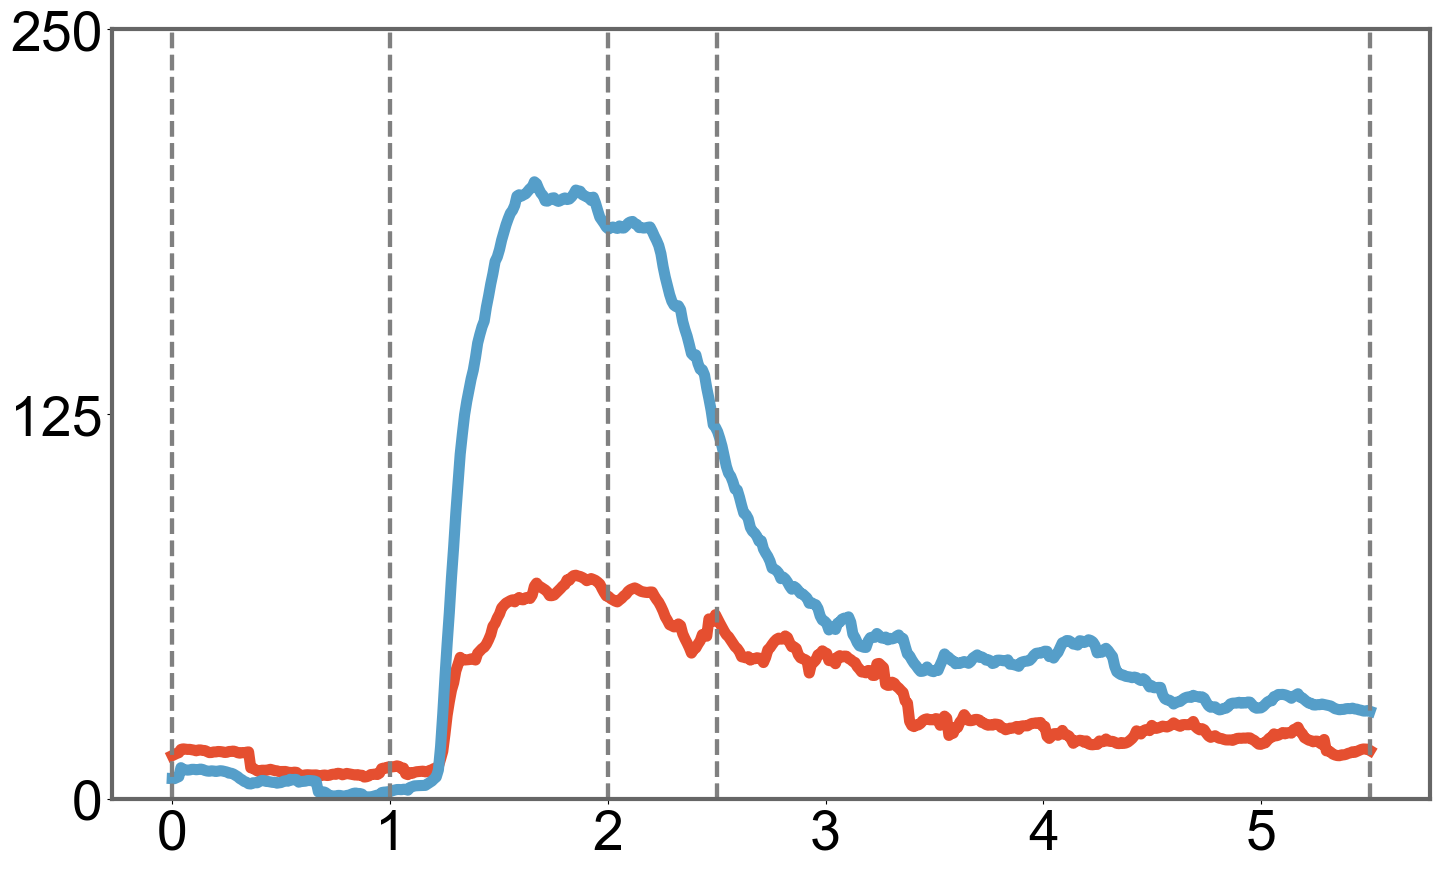

In [30]:
fs(17,10)

fig,ax = plt.subplots()
xaxis = np.linspace(0,5.5,550)

ax.plot(xaxis,np.linalg.norm(baseTrlGaze - targetTrl1Gaze,axis = 0),linewidth = 8,c = '#e54f30')
plt.ylim(0,250)
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1))
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(125))
plt.vlines(np.array([0.5,1.5,2.5,3,6])-0.5,0,250,colors = 'grey',linestyles = 'dashed',linewidth = 3)
plt.tick_params(axis='y', which='major', labelsize=40)
plt.tick_params(axis='x', which='major', labelsize=40)


plt.plot(xaxis,np.linalg.norm(baseTrlGaze - targetTrl2Gaze,axis = 0),linewidth = 8,c = '#559ec9')
plt.ylim(0,250)


plt.vlines(time,0,250,colors = 'grey',linestyles = 'dashed',linewidth = 3)
plt.tick_params(axis='y', which='major', labelsize=40)
plt.tick_params(axis='x', which='major', labelsize=40)

style_spines(ax)

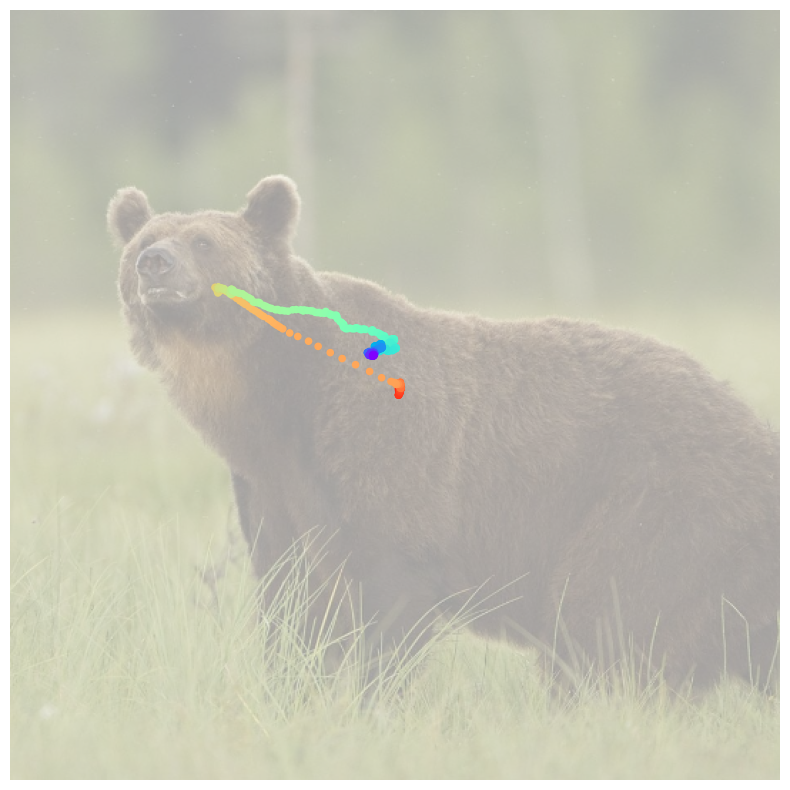

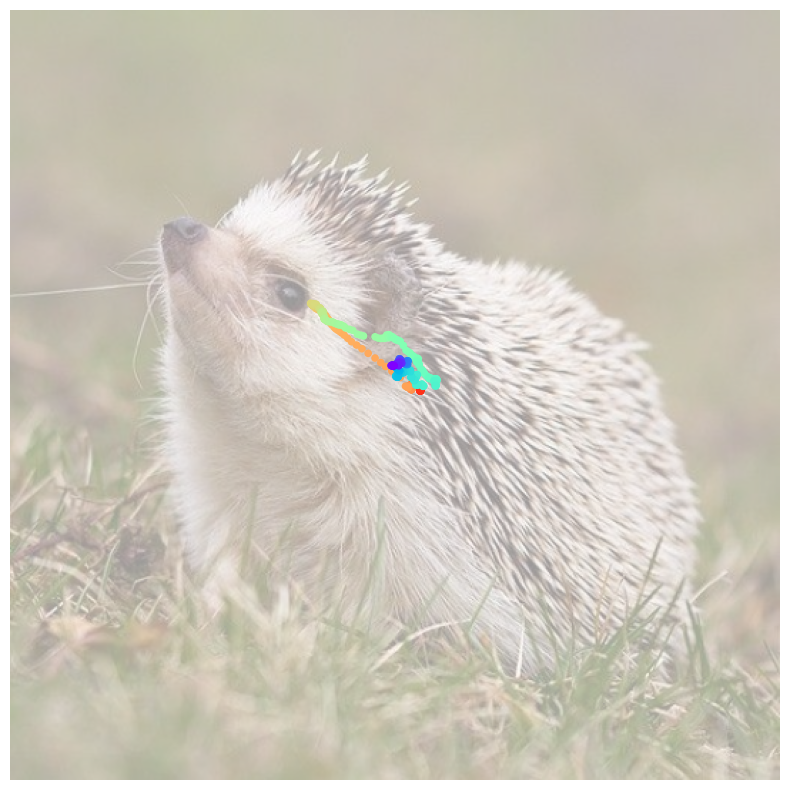

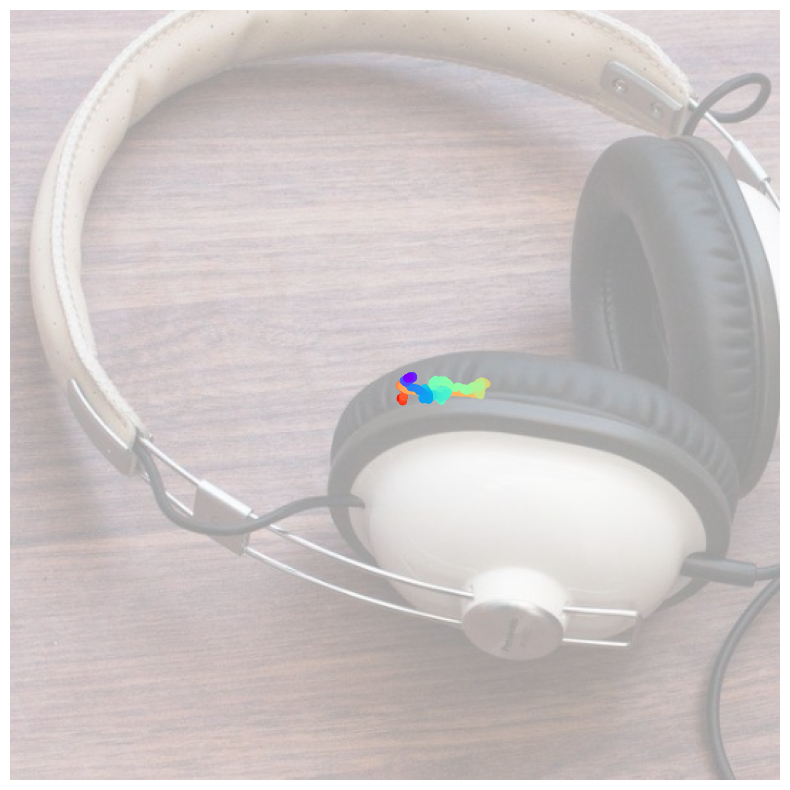

In [40]:
def show_expimage_with_gaze(filename, gaze, size=(540, 540)):
    img = cv2.imread('../expImages40/' + filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(cv2.resize(img, size), alpha=0.4)

    z = np.linspace(0, 1, gaze.shape[1])
    #recentering gaze coordinates to the center of the image (540x540)
    plt.scatter(gaze[0] - (1920/2 - 540/2), gaze[1] - (540/2), s=20, c=z, cmap='rainbow_r')
    plt.axis('off')
    plt.show()

fs(10, 10)

for img, gaze in ((baseImg, baseTrlGaze), (targetImg1, targetTrl1Gaze), (targetImg2, targetTrl2Gaze)):
    show_expimage_with_gaze(img, gaze)


# Figure 4B

In [47]:
task_id = '311to352' if task == 'precue' else '360to400'
rsa_data_root = f'{root}gRSA_euc/rsaByCondition/meanEuc/{task_id}/'

In [154]:
image_label_sorted = np.load('image_labels_sorted.npy',allow_pickle=True)

#load modeled similarity matrix, the last layer
verbal_rdv = pd.read_csv("vgg-16_classifiers.6.csv")

#load modeled similarity matrix from an earlier layer
visual_rdv = pd.read_csv("vgg-16_features23.csv")

### calculate gaze euc

In [ ]:
def compute_subject_rdv(subj, gazeClean, verbal_rdv, visual_rdv, trlInfo, dataN=600):

    """Compute empirical + model RDVs for one subject; returns tagsMean for that subject.
    run this if you want to get the euc for each subject, otherwise load the pre-computed tagsMean for all subjects from the csv file.
    (see gaze similarity between images section for the pre-computed tagsMean)
    """
    gazeThisSubj = gazeClean[gazeClean.participant == subj]
    trials = gazeThisSubj.TRIALID.unique()
    nTrl = len(trials)

    eucMat = np.zeros((nTrl, nTrl - 1, dataN))
    mRDVMat_visual = np.zeros((nTrl, nTrl - 1, 1))
    mRDVMat_verbal = np.zeros((nTrl, nTrl - 1, 1))
    trlTypeMat = np.empty((nTrl, nTrl - 1, 2), dtype=object)

    gazeX = gazeThisSubj[gazeThisSubj.axis == 'x']
    gazeY = gazeThisSubj[gazeThisSubj.axis == 'y']

    for trlNum, trl in enumerate(trials):
        thisTrl = gazeThisSubj[gazeThisSubj.TRIALID == trl]
        imageTrue = thisTrl.stimImage.values[0]

        restX = gazeX[gazeX.TRIALID != trl]
        restY = gazeY[gazeY.TRIALID != trl]

        # empirical RDV: Euclidean distance in gaze (x,y) between this trial and all others, per timepoint
        dx = restX.iloc[:, 2:dataN + 2].values - thisTrl[thisTrl.axis == 'x'].iloc[0, 2:dataN + 2].values
        dy = restY.iloc[:, 2:dataN + 2].values - thisTrl[thisTrl.axis == 'y'].iloc[0, 2:dataN + 2].values
        eucMat[trlNum] = np.linalg.norm(np.stack([dx, dy], axis=1).astype(float), axis=1)

        restImages = restX.stimImage.values
        mRDVMat_verbal[trlNum] = (1 - (verbal_rdv.loc[verbal_rdv['0'] == imageTrue, restImages].values + 1) / 2).T
        mRDVMat_visual[trlNum] = (1 - np.sqrt(visual_rdv.loc[visual_rdv['0'] == imageTrue, restImages].values)).T

        trlTypeMat[trlNum] = np.stack([restX.trlType.values, restX.TRIALID.values], axis=1)

    tags = pd.DataFrame(
        trlTypeMat.reshape(-1, 2),
        columns=['targetType', 'targetID'],
    )
    tags['currentID'] = np.repeat(trials, nTrl - 1)
    tags = pd.concat([pd.DataFrame(eucMat.reshape(-1, dataN)), tags], axis=1)
    tags = tags.merge(trlInfo, left_on='currentID', right_on='TRIALID')
    tags = tags.merge(trlInfo, left_on='targetID', right_on='TRIALID', suffixes=('_current', '_target'))

    tags['mRDV_visual'] = mRDVMat_visual.reshape(-1, 1)
    tags['mRDV_verbal'] = mRDVMat_verbal.reshape(-1, 1)

    tagsMean = tags.groupby(
        ['trlType_current', 'trlType_target', 'stimImage_current', 'stimImage_target']
    ).mean(numeric_only=True)
    tagsMean['subj'] = subj

    return tagsMean


dataN = 600
example_subj = gazeClean.participant.unique()[0]
tagsMean_example_subj = compute_subject_rdv(example_subj, gazeClean, verbal_rdv, visual_rdv, trlInfo, dataN=dataN)


In [165]:
tagsMean_example_subj

0  \
trlType_current trlType_target stimImage_current stimImage_target               
verbal          verbal         alligator_03n.jpg alligator_03n.jpg  23.543642   
                                                 alligator_13n.jpg  43.112187   
                                                 bear_08s.jpg       69.945468   
                                                 bear_21n.jpg       33.320243   
                                                 blind_17s.jpg      37.449945   
...                                                                       ...   
visual          visual         watch_10s.jpg     turtle_09n.jpg     66.035293   
                                                 wallpaper_01b.jpg  58.899385   
                                                 wallpaper_04s.jpg  53.599971   
                                                 watch_05s.jpg      60.212592   
                                                 watch_10s.jpg      76.752974   

                                                                            1  \
trlType_current trlType_target stimImage_current stimImage_target               
verbal          verbal         alligator_03n.jpg alligator_03n.jpg  23.571355   
                                                 alligator_13n.jpg  43.172184   
                                                 bear_08s.jpg       69.830080   
                                                 bear_21n.jpg       33.307648   
                                                 blind_17s.jpg      37.416409   
...                                                                       ...   
visual          visual         watch_10s.jpg     turtle_09n.jpg     66.099886   
                                                 wallpaper_01b.jpg  58.878583   
                                                 wallpaper_04s.jpg  53.695190   
                                                 watch_05s.jpg      60.728732   
                                                 watch_10s.jpg      76.730946   

                                                                            2  \
trlType_current trlType_target stimImage_current stimImage_target               
verbal          verbal         alligator_03n.jpg alligator_03n.jpg  23.072516   
                                                 alligator_13n.jpg  42.885673   
                                                 bear_08s.jpg       69.836353   
                                                 bear_21n.jpg       33.307562   
                                                 blind_17s.jpg      37.358876   
...                                                                       ...   
visual          visual         watch_10s.jpg     turtle_09n.jpg     66.186102   
                                                 wallpaper_01b.jpg  58.407050   
                                                 wallpaper_04s.jpg  50.727124   
                                                 watch_05s.jpg      61.359245   
                                                 watch_10s.jpg      76.524145   

                                                                            3  \
trlType_current trlType_target stimImage_current stimImage_target               
verbal          verbal         alligator_03n.jpg alligator_03n.jpg  23.224828   
                                                 alligator_13n.jpg  42.949232   
                                                 bear_08s.jpg       69.793168   
                                                 bear_21n.jpg       33.228177   
                                                 blind_17s.jpg      37.374668   
...                                                                       ...   
visual          visual         watch_10s.jpg     turtle_09n.jpg     67.208779   
                                                 wallpaper_01b.jpg  59.081362   
                                                 wallpaper_04s.jpg  52.570593   
                       

### modeled similarity

In [ ]:
#normalize to -1,1
verbal_rdv.set_index('0',inplace=True)
verbal_rdv = (1- (verbal_rdv +1)/2 )
modeled_similarity = verbal_rdv.loc[image_label_sorted,image_label_sorted]


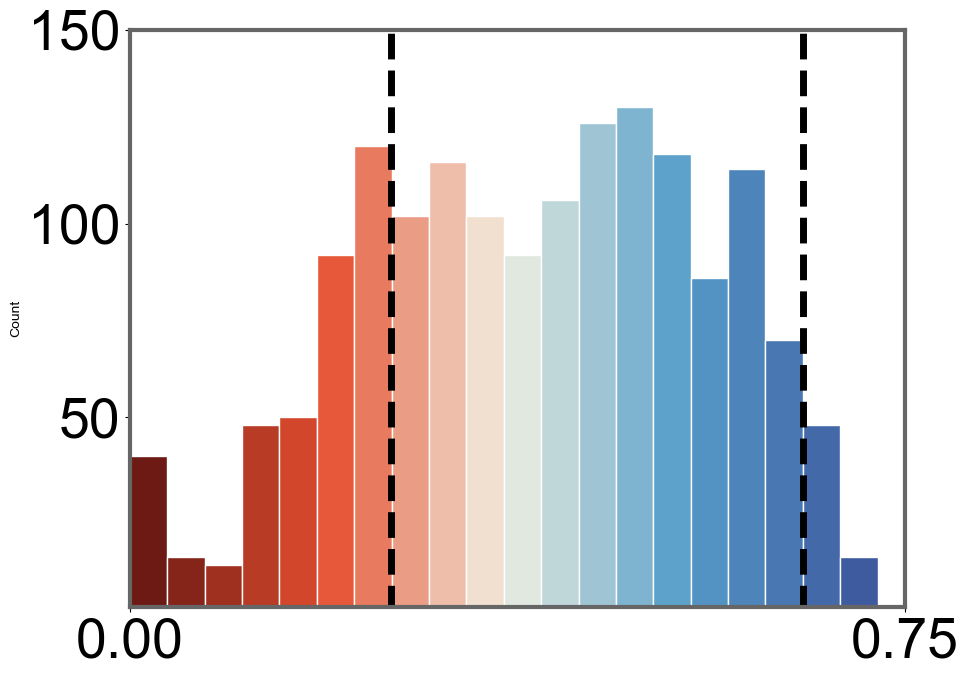

In [144]:
fs(10,7.5)

colors = [ '#3f5ba0','#559ec9','#f2f1e2','#e54f30','#6c1a13'][::-1] 
binNum = 20

ax = sns.histplot(np.ravel(modeled_similarity),bins = 20)
#create the colored bins
cm = LinearSegmentedColormap.from_list(
        "Custom", colors, N=binNum)
[p.set(color = cm(n),linewidth = 1,edgecolor = 'white') for n,p in enumerate(ax.patches)]
ax.tick_params(labelsize=40)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(50))
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(0.75))

plt.vlines([qqq.loc[baseImg,targetImg1,],qqq.loc[baseImg,targetImg2,]],0,150,linestyles='dashed',colors='black',linewidth = 5)

plt.xlim(0,0.75)
plt.ylim(1,150)


style_spines(ax)

(-0.5, 39.5, 39.5, -0.5)

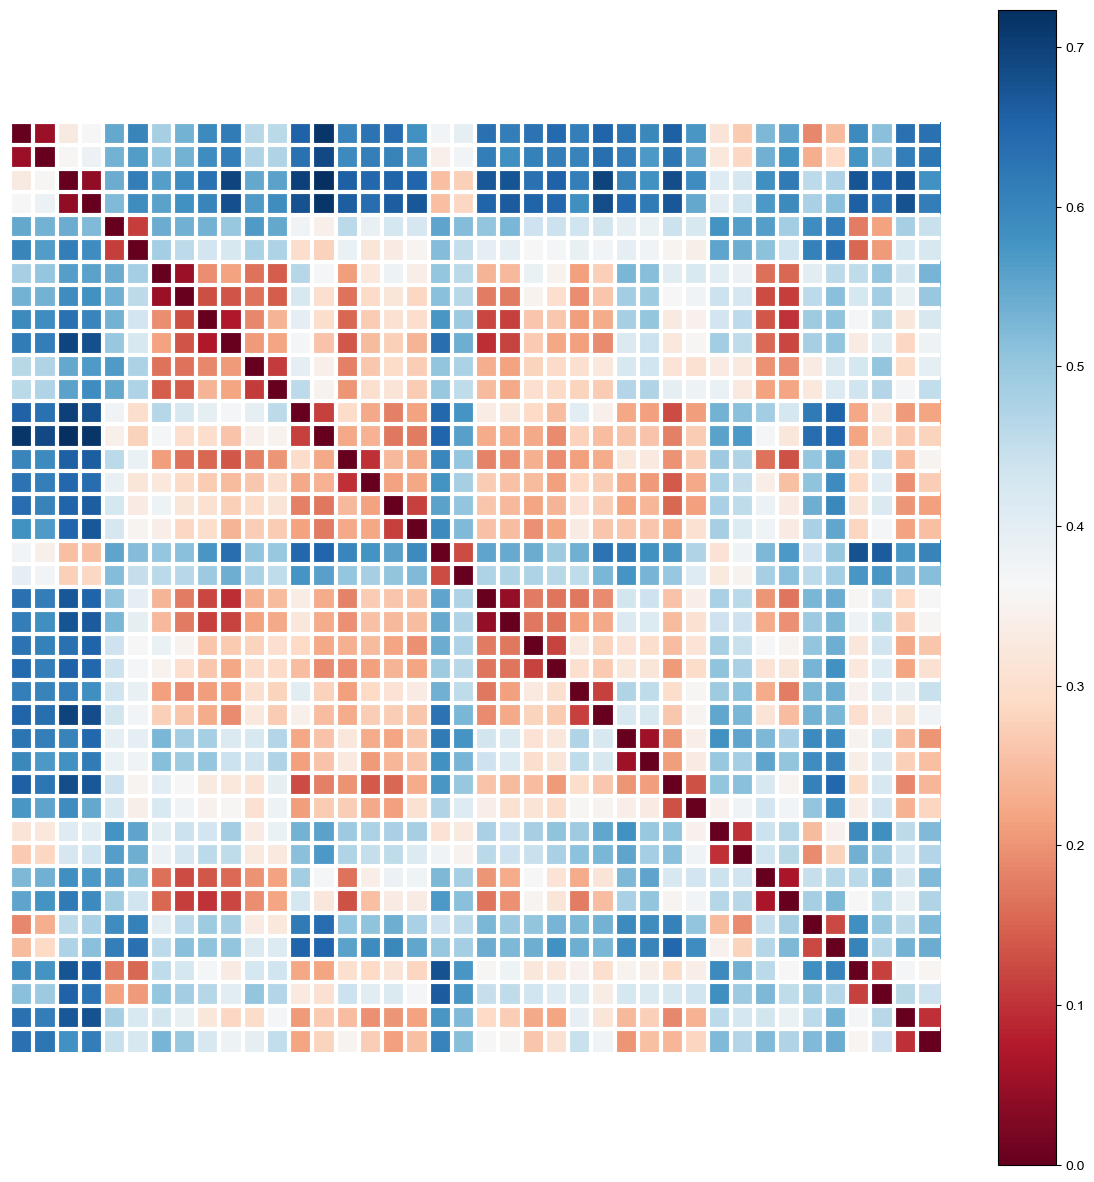

In [119]:
fs(15,15)
f = plt.imshow(modeled_similarity,cmap = 'RdBu')

#add in the grids
plt.vlines(np.arange(0,39.6,1)-0.5,-0.5, 39.5,
            colors='white',linewidth = 3)
plt.hlines(np.arange(0,39.6,1)-0.5,-0.5, 39.5,
            colors='white',linewidth = 3)

plt.colorbar(f)
plt.axis('off')

### gaze similarity between images

In [137]:
allSubj = []

for n, thisFile in enumerate(glob.glob(f'{rsa_data_root}*.csv')):
    tagsMean = pd.read_csv(thisFile)

    visualOnly = tagsMean[(tagsMean.trlType_current == 'visual') &
                          (tagsMean.trlType_target == 'visual')].reset_index(drop=True)

    #get the mean value of the entire 5.5s
    visualOnly['meanEuc'] = visualOnly.iloc[:, 54:604].mean(axis=1)

    simMat = visualOnly.pivot(index='stimImage_current', columns='stimImage_target', values='meanEuc')
    simMat = simMat.reindex(index=image_label_sorted, columns=image_label_sorted)  # fixed 40x40; missing pairs -> NaN

    normalized_simMat = simMat.values - np.nanmean(simMat.values)
    normalized_simMat = normalized_simMat/np.nanstd(normalized_simMat)

    allSubj.append(normalized_simMat)

(-0.5, 39.5, 39.5, -0.5)

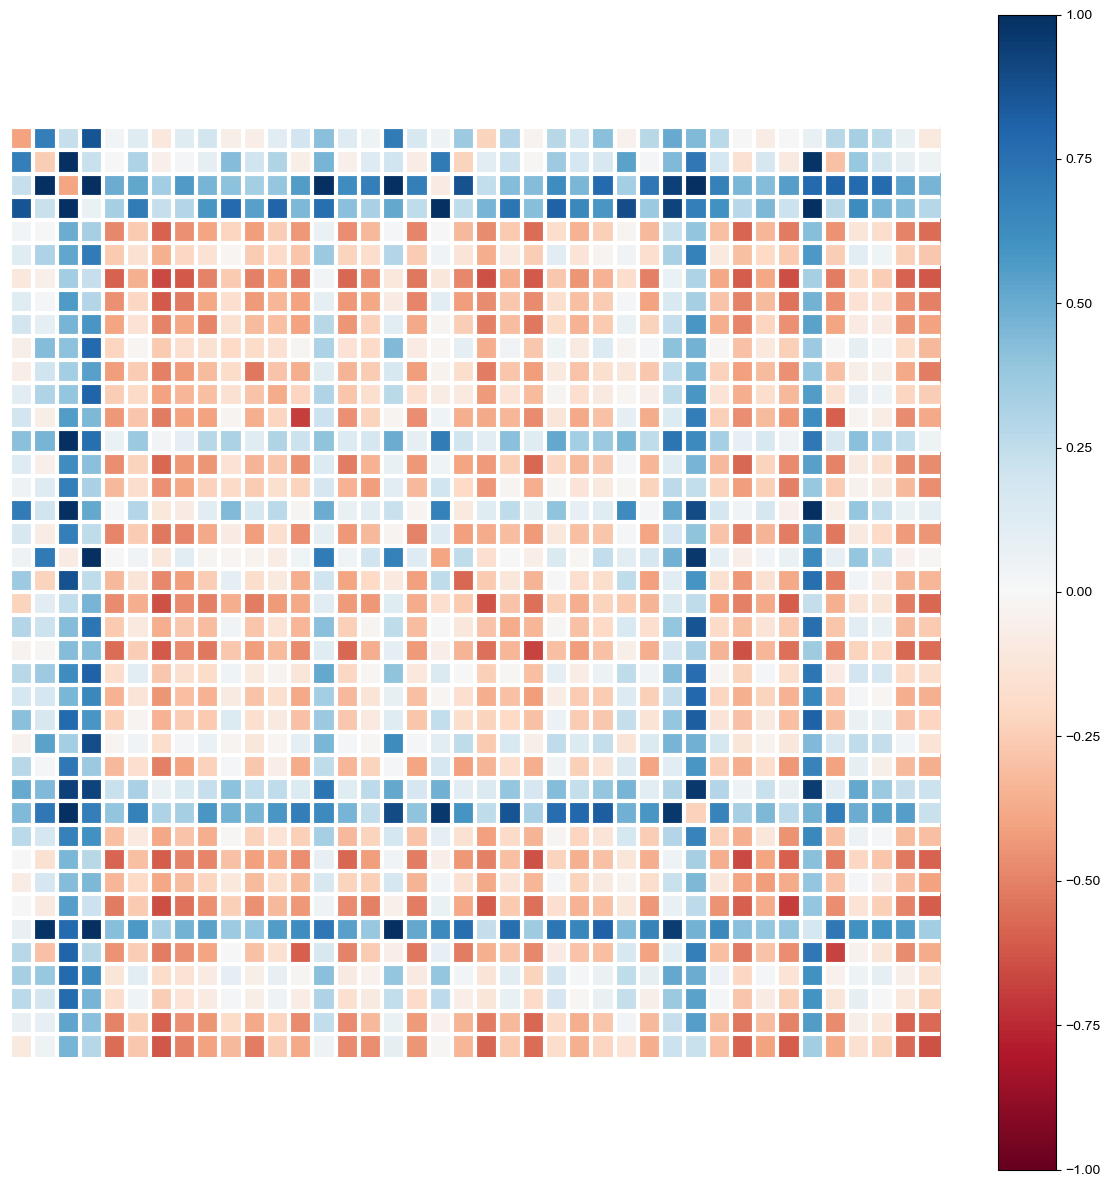

In [140]:
fs(15,15)
im = plt.imshow(np.nanmean(allSubj, axis=0), vmax=1,vmin=-1,cmap = 'RdBu',)
plt.vlines(np.arange(0,39.6,1)-0.5,-0.5, 39.5,
            colors='white',linewidth = 3)
plt.hlines(np.arange(0,39.6,1)-0.5,-0.5, 39.5,
            colors='white',linewidth = 3)

plt.colorbar(im)
plt.axis('off')

# Figure 4C

In [290]:
def allCorr(tagsMean,subj,included = 600,corrType = None,**kwargs,):
    """
    default rdv is the last layer of the vgg16 classifier, which is the most abstract representation of the image.
    """
    
   
    allArr = np.zeros((3,included))

    allArr[0] = [tagsMean.loc['verbal','verbal'].iloc[:,k].corr(tagsMean.loc['verbal','verbal'][corrType])for k in range(included)]
    allArr[1]  = [tagsMean.loc['verbal','visual'].iloc[:,k].corr(tagsMean.loc['verbal','visual'][corrType])for k in range(included)]
    allArr[2]  = [tagsMean.loc['visual','visual'].iloc[:,k].corr(tagsMean.loc['visual','visual'][corrType])for k in range(included)]
    
    outDf = pd.DataFrame(allArr)
    outDf['mRDV'] = corrType
    outDf['current'] = ['verbal','verbal','visual'] 
    outDf['target'] = ['verbal','visual','visual'] 
    outDf['subj'] = subj

    return outDf

In [ ]:
max_pool_n_fc = np.array(['vgg16\\corr_vgg-16_features.6.npy',
'vgg16\\corr_vgg-16_features.13.npy',
'vgg16\\corr_vgg-16_features.23.npy',
'vgg16\\corr_vgg-16_features.33.npy',
'vgg16\\corr_vgg-16_features.43.npy',
'vgg16\\corr_vgg-16_classifiers.0.npy',
'vgg16\\corr_vgg-16_classifiers.3.npy',
'vgg16\\corr_vgg-16_classifiers.6.npy',])

layerLabels_full = ['max pooling layer 1', 'max pooling layer 2','max pooling layer 3',
'max pooling layer 4','max pooling layer 5', 
'fully connected layer 1','fully connected layer 2','fully connected layer 3']

layerLabels = ['MP 1', 'MP 2','MP 3',
'MP 4','MP 5', 
'FC 1','FC 2','FC 3']

imIDArr = np.load('D:/yueying/vgg16_it_v2/trlInfo/filename_vgg-16_classifiers.6.npy')


In [259]:
dataN = 600
if downsample:
    dsFreq = 10
else:
    dsFreq = 1
howMuchToInclude = int(dataN / dsFreq)

task_ids = {'precue': '311to352', 'retrocue': '360to400'} 
dsCorr_by_task = {}

for task_name, task_id in task_ids.items():
    dsCorr = pd.DataFrame()

    for thisFile in glob.glob(f'{root}/gRSA_euc/rsaByCondition/meanEuc/{task_id}/*.csv'):
        tagsMean = pd.read_csv(thisFile)
        thisSubj = tagsMean.subj.values[0]
        print(thisSubj)

        #select only the relevant columns, and downsample if necessary
        tagsMean = pd.concat([tagsMean[['trlType_current', 'trlType_target', 'stimImage_current',
            'stimImage_target',
            ]], tagsMean.iloc[:, 4:dataN + 4].groupby(np.arange(dataN) // dsFreq, axis=1).mean(numeric_only=True)], axis=1)
        current_image, target_image = tagsMean.stimImage_current, tagsMean.stimImage_target
        tagsMean = tagsMean.set_index(['trlType_current', 'trlType_target', 'stimImage_current', 'stimImage_target'])

        for this_vgg_layer, this_layer_label in zip(max_pool_n_fc, layerLabels):
            print(this_layer_label)
            this_vgg_layer_value = pd.DataFrame(np.load(this_vgg_layer), index=imIDArr, columns=imIDArr)
            tagsMean[this_layer_label] = [1 - this_vgg_layer_value.loc[curr, tar] for curr, tar in zip(current_image, target_image)]

            #calculate the vgg value for this layer
            dsCorr = pd.concat([dsCorr,
                       allCorr(
                        tagsMean, thisSubj,
                        included=howMuchToInclude,
                        corrType=this_layer_label
                        )
            ], axis=0)

    dsCorr_by_task[task_name] = dsCorr

dsCorr_precue = dsCorr_by_task['precue']
dsCorr_retrocue = dsCorr_by_task['retrocue']


311.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
312.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
313.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
314.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
315.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
316.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
317.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
318.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
319.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
320.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
321.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
322.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
324.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
325.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
326.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
327.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
328.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
329.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
330.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
331.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
332.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 1
FC 2
FC 3
333.0
MP 1
MP 2
MP 3
MP 4
MP 5
FC 

In [235]:
cmap = plt.cm.get_cmap('viridis')
cmap2 = plt.cm.get_cmap('inferno')
retrocueT = np.array([0.5,1.5,2,2.5,3,6])
precueT = np.array([0.5,1.5,2.5,3,6])
layerN = dsCorr_precue_allLayer.mRDV.nunique()

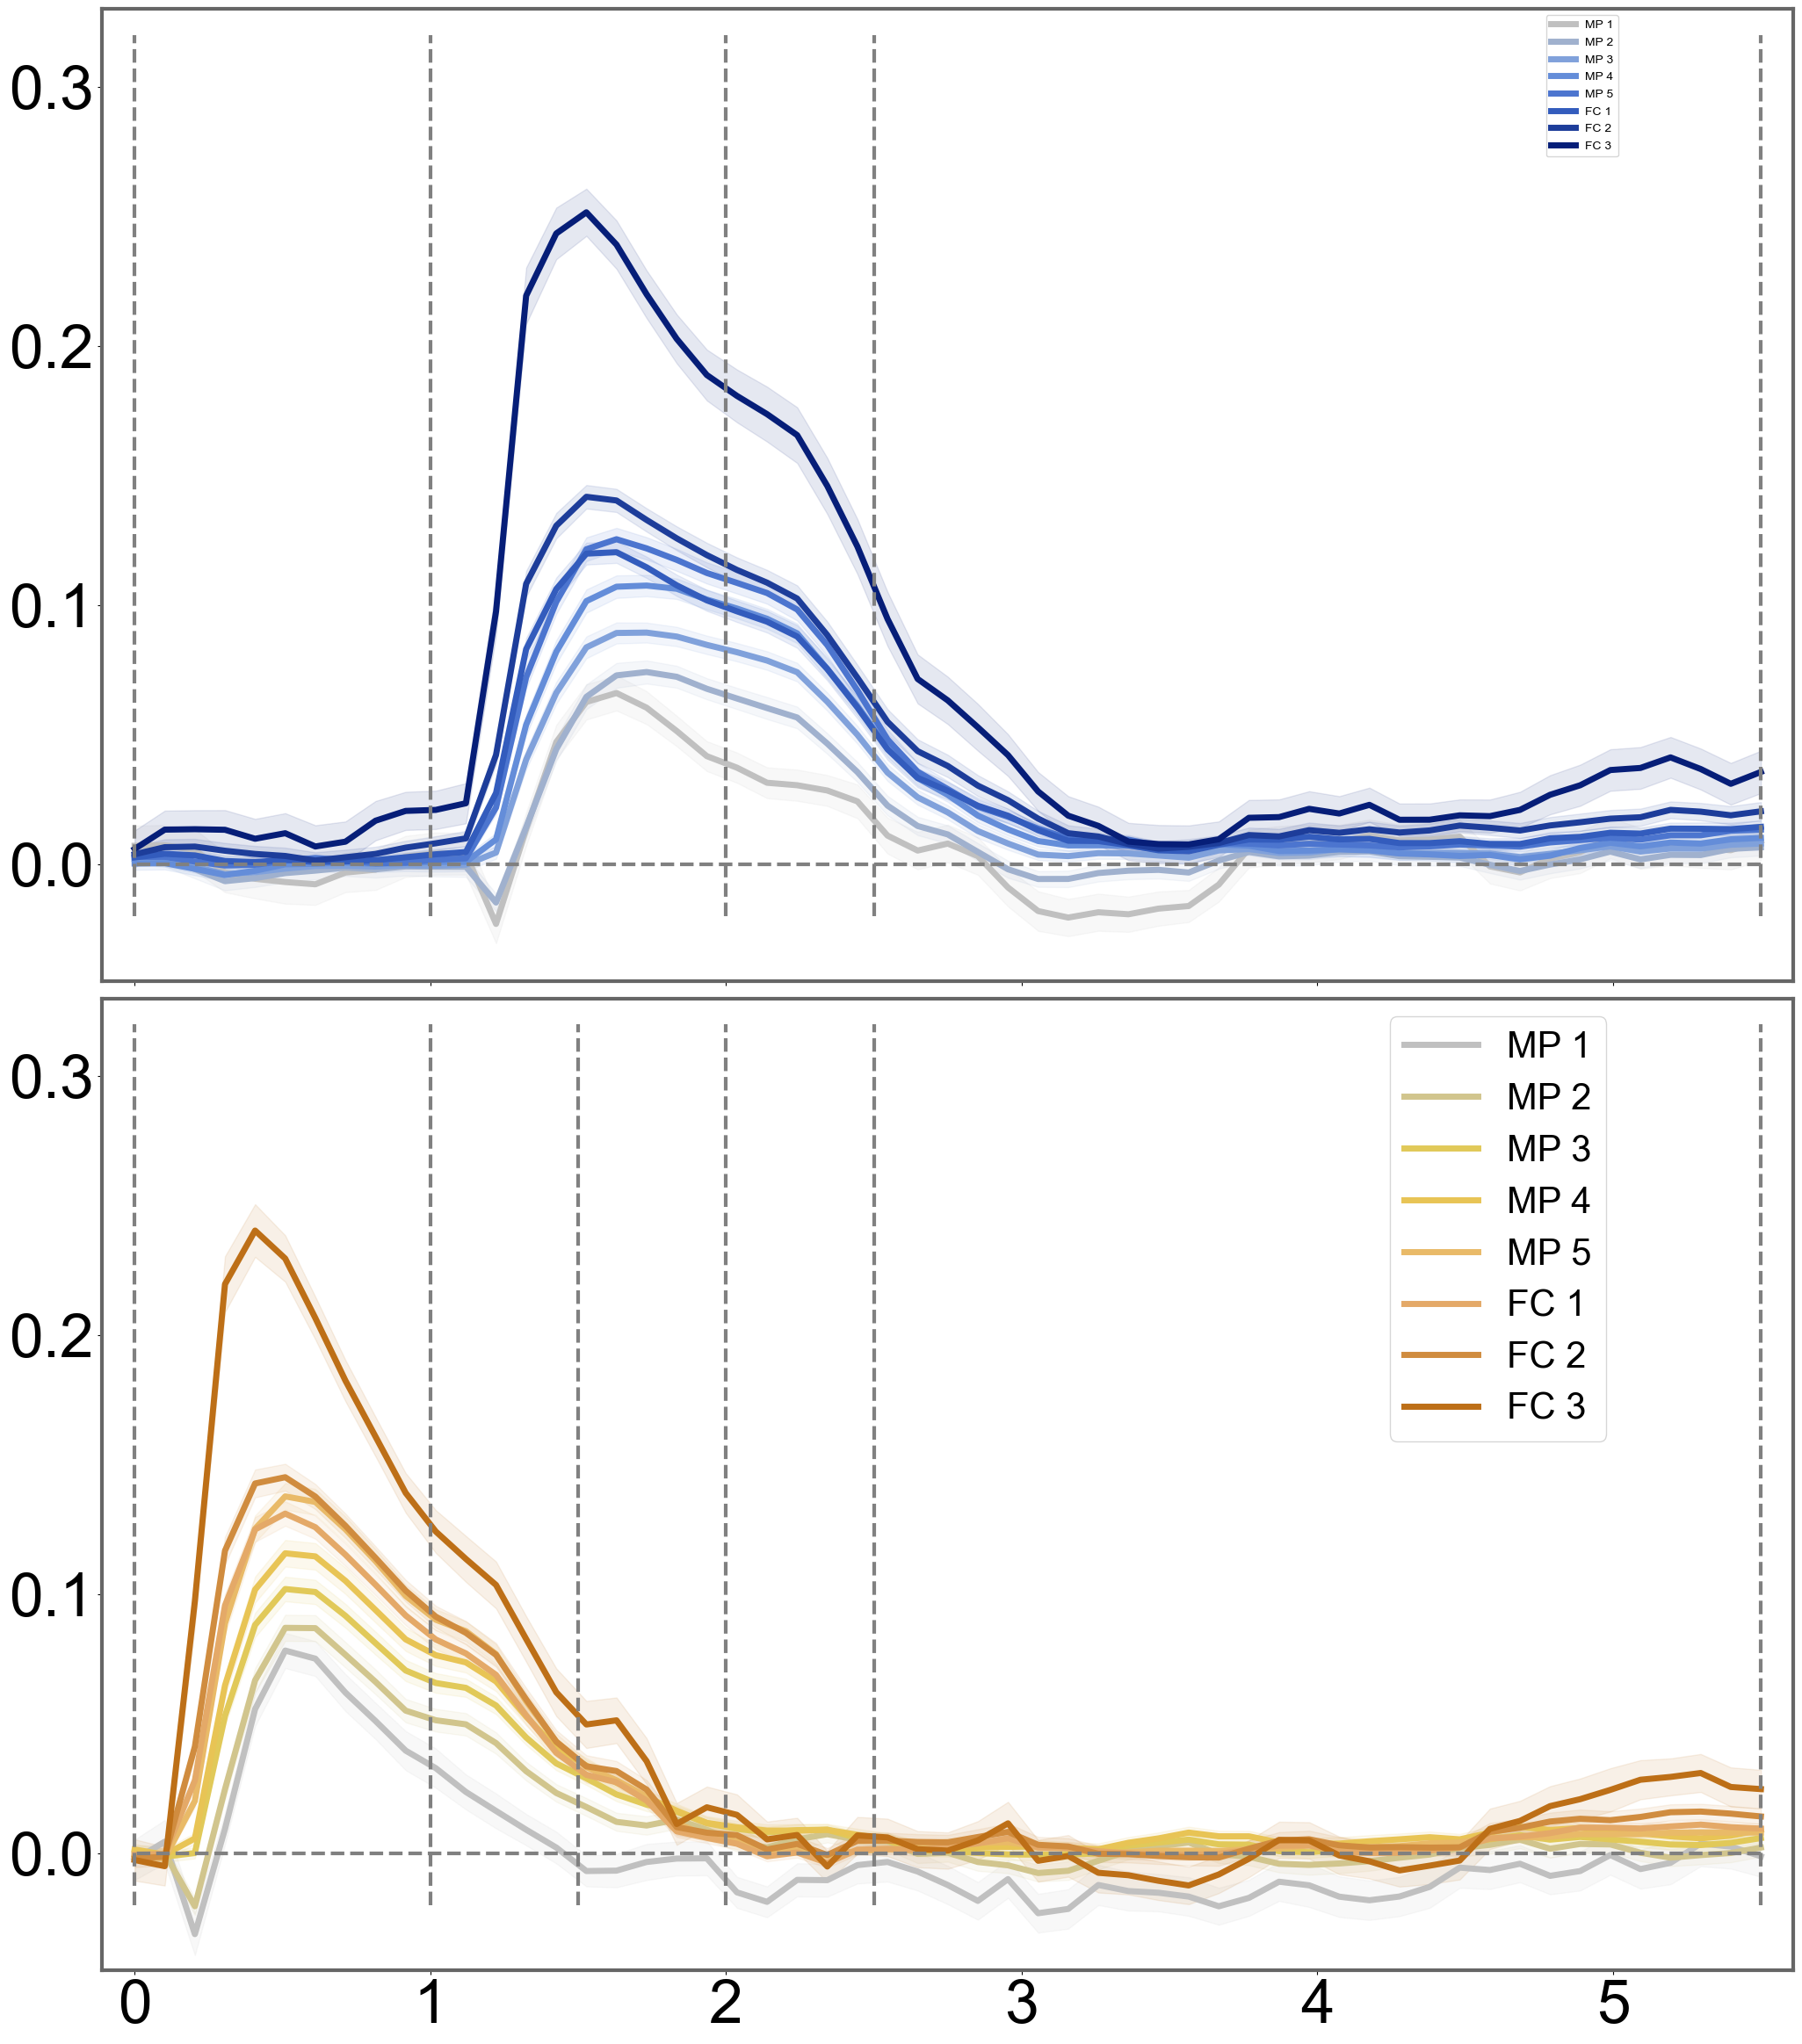

In [269]:
cm = LinearSegmentedColormap.from_list(
                "Custom", ['silver','#759ce0','#3b66c8','#061e78'], N=8)
cm2 = LinearSegmentedColormap.from_list(
                "Custom", ['silver','#e7cb48','#eab375','#bd6f17'], N=8)
dsCorrMean_precue = dsCorr_precue.groupby(['mRDV',]).mean(numeric_only=True).loc[layerLabels,np.arange(60)].iloc[:,5:60]
dsCorrSem_precue = dsCorr_precue.groupby(['mRDV',]).sem(numeric_only=True).loc[layerLabels,np.arange(60)].iloc[:,5:60]
dsCorrMean_retrocue = dsCorr_retrocue.groupby(['mRDV']).mean(numeric_only=True).loc[layerLabels,np.arange(60)].iloc[:,5:60]
dsCorrSem_retrocue = dsCorr_retrocue.groupby(['mRDV']).sem(numeric_only=True).loc[layerLabels,np.arange(60)].iloc[:,5:60]

xAxis = np.linspace(0,5.5,55)

fig,ax = plt.subplots(nrows=2,figsize = (20,23),sharex=True,sharey=True)

[ax[0].plot(xAxis,dsCorrMean_precue.iloc[i,:],linewidth = 5,label = layerLabels[i],
        color = cm(i)) for i in range (layerN) ]#label = mRDVs_corrLabel[i],
ax[0].legend(bbox_to_anchor = [0.9,1])

[ax[0].fill_between(xAxis,dsCorrMean_precue.iloc[i,:]+dsCorrSem_precue.iloc[i,:],dsCorrMean_precue.iloc[i,:]-dsCorrSem_precue.iloc[i,:],
        color = cm(i),alpha = 0.1) for i in range (layerN) ]#label = mRDVs_corrLabel[i],


ax[0].vlines(precueT-0.5,-0.02,0.32,colors = 'grey',linestyles = 'dashed',linewidth = 3)
plt.suptitle('')


[ax[1].plot(xAxis,dsCorrMean_retrocue.iloc[i,:],linewidth = 5,label = layerLabels[i],
        color = cm2(i)) for i in range (layerN) ]

ax[1].legend(fontsize = 30,bbox_to_anchor = (0.9,1))

[ax[1].fill_between(xAxis,dsCorrMean_retrocue.iloc[i,:]+dsCorrSem_retrocue.iloc[i,:],dsCorrMean_retrocue.iloc[i,:]-dsCorrSem_retrocue.iloc[i,:],
        label = dsCorrMean_retrocue.index.values[i],color = cm2(i),alpha = 0.1) for i in range (layerN) ]
ax[1].vlines(retrocueT-0.5,-0.02,0.32,colors = 'grey',linestyles = 'dashed',linewidth = 3)

ax[0].set_title('')
ax[1].set_title('')
fig.tight_layout()

ax[0].yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax[1].yaxis.set_major_locator(ticker.MultipleLocator(0.1))

#ax[0].legend(fontsize = 30,bbox_to_anchor = (0.5,1))



ax[0].set_ylim(-0.045,0.33)

ax[0].tick_params(axis = 'y',labelsize=50)
ax[0].tick_params(axis = 'x',labelsize=0)
ax[1].tick_params(labelsize=50)
ax[0].hlines(0,5.5,0,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].hlines(0,5.5,0,colors = 'grey',linestyles = 'dashed',linewidth = 3)


ax[0].spines['left'].set_color('#666666')
ax[0].spines['bottom'].set_color('#666666')
ax[0].spines['right'].set_color('#666666')
ax[0].spines['top'].set_color('#666666')
ax[0].spines['left'].set_linewidth(3)
ax[0].spines['bottom'].set_linewidth(3)
ax[0].spines['right'].set_linewidth(3)
ax[0].spines['top'].set_linewidth(3)

ax[1].spines['left'].set_color('#666666')
ax[1].spines['bottom'].set_color('#666666')
ax[1].spines['right'].set_color('#666666')
ax[1].spines['top'].set_color('#666666')
ax[1].spines['left'].set_linewidth(3)
ax[1].spines['bottom'].set_linewidth(3)
ax[1].spines['right'].set_linewidth(3)
ax[1].spines['top'].set_linewidth(3)

ax[0]. margins(x=0.02)

# Figure 4D

In [291]:
dataN = 600
downsample = False
if downsample:
    dsFreq = 10
else:
    dsFreq = 1
howMuchToInclude = int(dataN / dsFreq)

task_ids = {'precue': '311to352', 'retrocue': '360to400'} 
dsCorr_by_task_last_layer = {}
last_vgg_layer = 'vgg16\\corr_vgg-16_classifiers.6.npy'
last_vgg_layer_value = pd.DataFrame(np.load(last_vgg_layer), index=imIDArr, columns=imIDArr)


for task_name, task_id in task_ids.items():
    dsCorr = pd.DataFrame()

    for thisFile in glob.glob(f'{root}/gRSA_euc/rsaByCondition/meanEuc/{task_id}/*.csv'):
        tagsMean = pd.read_csv(thisFile)
        thisSubj = tagsMean.subj.values[0]
        print(thisSubj)

        #select only the relevant columns, and downsample if necessary
        tagsMean = pd.concat([tagsMean[['trlType_current', 'trlType_target', 'stimImage_current',
            'stimImage_target',
            ]], tagsMean.iloc[:, 4:dataN + 4].groupby(np.arange(dataN) // dsFreq, axis=1).mean(numeric_only=True)], axis=1)
        current_image, target_image = tagsMean.stimImage_current, tagsMean.stimImage_target
        tagsMean = tagsMean.set_index(['trlType_current', 'trlType_target', 'stimImage_current', 'stimImage_target'])
        tagsMean['FC 3'] = [1 - last_vgg_layer_value.loc[curr, tar] for curr, tar in zip(current_image, target_image)]

        #calculate the vgg value for this layer
        dsCorr = pd.concat([dsCorr,
                    allCorr(
                    tagsMean, thisSubj,
                    included=howMuchToInclude,
                    corrType='FC 3'
                    )
        ], axis=0)

    dsCorr_by_task_last_layer[task_name] = dsCorr

dsCorr_precue_last_layer = dsCorr_by_task_last_layer['precue']
dsCorr_retrocue_last_layer = dsCorr_by_task_last_layer['retrocue']


311.0
312.0
313.0
314.0
315.0
316.0
317.0
318.0
319.0
320.0
321.0
322.0
324.0
325.0
326.0
327.0
328.0
329.0
330.0
331.0
332.0
333.0
334.0
335.0
336.0
337.0
338.0
339.0
340.0
341.0
342.0
343.0
344.0
345.0
346.0
347.0
348.0
349.0
350.0
351.0
352.0
112430.0
360.0
362.0
363.0
364.0
365.0
366.0
367.0
368.0
369.0
370.0
371.0
372.0
373.0
374.0
375.0
376.0
377.0
378.0
379.0
380.0
381.0
382.0
383.0
384.0
385.0
386.0
387.0
388.0
389.0
390.0
391.0
392.0
393.0
394.0
395.0
396.0
397.0
398.0
399.0
400.0


## permutation (comparison groups)

In [ ]:
dataN = 60
perms = 1000
runRaw = True


### precue

In [380]:
last_layer_precue = dsCorr_precue[dsCorr_precue.mRDV == 'FC 3']
last_layer_precue['comparison'] = last_layer_precue.current + last_layer_precue.target
precue_comparison_condition_test = np.array([pg.rm_anova(data = last_layer_precue, dv = i,subject='subj',
                within = ['comparison'],)[['F','p-unc']].iloc[0,:] for i in last_layer_precue.columns[5:dataN].values])
p = precue_comparison_condition_test[:,1]


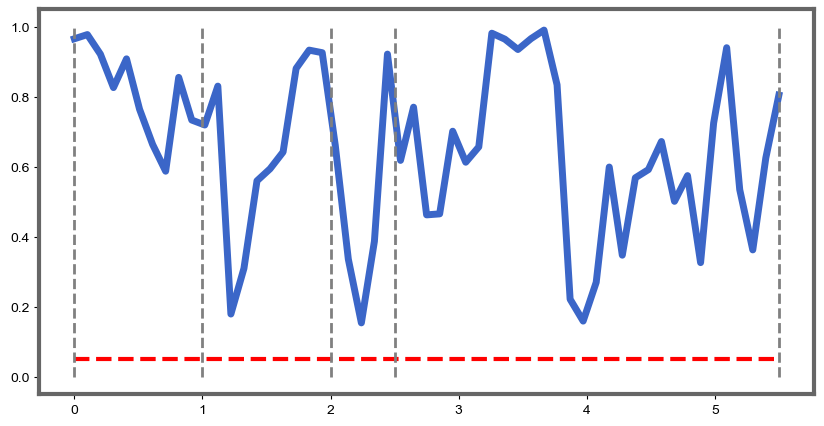

In [381]:
fs(10,5)
plt.plot(np.linspace(0,5.5,55),p,color = '#3b66c8',linewidth = 5)
plt.hlines(0.05,0,5.5,colors = 'red',linestyles = 'dashed',
    linewidth = 3)
plt.vlines(precue_T,0,1,colors = 'grey',linestyles = 'dashed',linewidth = 2)

style_spines(plt.gca())

### retrocue

In [382]:
last_layer_retrocue = dsCorr_retrocue[dsCorr_retrocue.mRDV == 'FC 3']
last_layer_retrocue['comparison'] = last_layer_retrocue.current + last_layer_retrocue.target
retrocue_comparison_condition_test = np.array([pg.rm_anova(data = last_layer_retrocue, dv = i,subject='subj',
                within = ['comparison'],)[['F','p-unc']].iloc[0,:] for i in last_layer_retrocue.columns[5:dataN].values])
p = retrocue_comparison_condition_test[:,1]


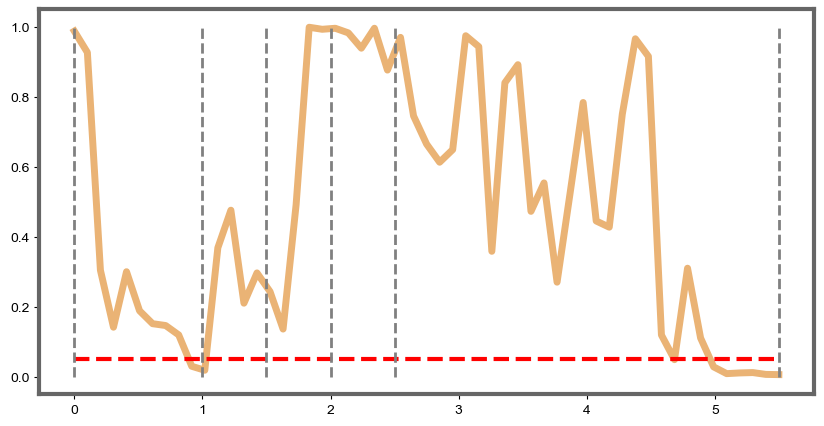

In [384]:
fs(10,5)
plt.plot(np.linspace(0,5.5,55),p,color = '#eab375',linewidth = 5)
plt.hlines(0.05,0,5.5,colors = 'red',linestyles = 'dashed',
    linewidth = 3)
plt.vlines(retrocue_T,0,1,colors = 'grey',linestyles = 'dashed',linewidth = 2)

style_spines(plt.gca())

In [ ]:
fCluster_retrocue_comparison_condition = np.zeros(perms) # permutation iteration x data x f and p 
if runRaw:
        
        for n in range(perms):
                print(n)
                
                # shuffle condition label
                dsCorr_retrocue['randLabel'] = np.random.permutation(dsCorr_retrocue.comparison.values)

                # for each time point, 2 way anova with blk reliability and cued item as dv, and the data as dv
                # get the f score for the interaction effect
                fpThis = np.array([pg.rm_anova(data = dsCorr_retrocue, dv = i,subject='subj',
                within = ['randLabel'],)[['F','p-unc']].iloc[0,:] for i in dsCorr_retrocue.columns[5:dataN].values])
                fArr = fpThis[:,0]

                # find the clusters that exceed p value threshold
                consGroups = consecutive(np.where(fpThis[:,1] < 0.05)[0], stepsize=1,
                                findSame = False)

                # find the cluster with the largest length,then find its corresponding t values, sum it up
                        #note: if no cluster is found, this will return 0
                fCluster_retrocue_comparison_condition[n] =  np.round(fArr[consGroups[np.argmax(np.array([len(t) for t in consGroups]))]].sum(),3)
else:
        fCluster_retrocue_comparison_condition = np.load('D:/yueying/gazeObject_YueyingDong/results/gRSA_euc/rsaByCondition/corrVal/fCluster_retrocue_rmAnova.npy')


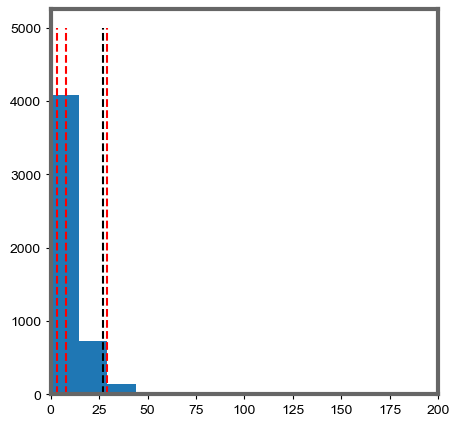

In [390]:
fs(5,5)
realF = np.array(retrocue_comparison_condition_test)[:,0]
realP = np.array(retrocue_comparison_condition_test)[:,1]

consGroups_retrocueCond = consecutive(np.where(realP <= 0.05)[0], stepsize=1,
                        findSame = False)
fsum_retrocueCond = [realF[i].sum() for i in consGroups_retrocueCond]
pValue_retrocueCond = [sum(fCluster_retrocue_comparison_condition > i)/perms for i in fsum_retrocueCond]

plt.hist(fCluster_retrocue_comparison_condition,bins = 20)
plt.vlines([fsum_retrocueCond],0,perms,linestyles = 'dashed',color ='r')
plt.vlines(np.percentile(fCluster_retrocue_comparison_condition,95),0,perms,linestyles = 'dashed',color ='black')
plt.xlim(0,200)

style_spines(plt.gca())


In [400]:
significance_retrocue_comparison_condition = np.array(consGroups_retrocueCond,dtype=object)[np.where(np.array(pValue_retrocueCond) < 0.05)[0]]

In [404]:
significance_retrocue_comparison_condition

array([array([49, 50, 51, 52, 53, 54], dtype=int64)], dtype=object)

In [415]:
[print(
f"significant clusters for retrocue comparison condition: \n\
    {i[0]/10} to {i[-1]/10 +0.1} seconds" # correct for the downsampled data
) for i in significance_retrocue_comparison_condition]

significant clusters for retrocue comparison condition: 
    4.9 to 5.5 seconds


[None]

## one sample test

In [420]:
def oneSampTTest(data, **kwargs):

    return stats.ttest_1samp(data,**kwargs) #t,p

def rmAnovaTest(data,dataN, level,**kwargs): 
    #dataN is the number of columns to ran the test on, this is needed because usually the last few columns are labels
    #level decides which variable's f and p value to get
    return np.array([pg.rm_anova(data = data, dv = i,**kwargs)[['F','p-unc']].iloc[level,:] for i in data.columns[:dataN].values])

def permutationFunction(test,**kwargs):
    testFunctions = {
        'oneSampleTTest': oneSampTTest,
        'rmAnovaTest': rmAnovaTest
    }
    if test in testFunctions:
        return testFunctions[test](**kwargs)
    else:
        raise ValueError(f"Invalid test type: {test}")
    
def runPerm(testType,perms,data,dataN,permLevel,**kwargs):
        fCluster = np.zeros(perms)   
        
        for n in range(perms):
                print(n)
                try:
                        # shuffle condition label
                        data['randLabel'] = np.random.permutation(data[permLevel].values)

                        # calcualte the permutated statistic (e.g. F values, t values) and p values
                        statArr,pArr = permutationFunction(testType,data = data.iloc[:,:dataN],**kwargs)
                        
                        # find the clusters that exceed p value threshold
                        consGroups = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)

                        # find the cluster with the largest length,then find its corresponding t values, sum it up
                                #note: if no cluster is found, this will return 0
                        fCluster[n] =  np.round(statArr[consGroups[np.argmax(np.array([len(t) for t in consGroups]))]].sum(),3)

                except ZeroDivisionError:
                        print(f"⚠️ calculation encountered for {i}. Skipping.")
        return fCluster

In [421]:
perms = 5000
fCluster = np.zeros((3,perms))
loadRaw = False

In [ ]:
if loadRaw:
    for labelCnt,label in enumerate(['verbalverbal','verbalvisual','visualvisual']):
        dataThis = semanticCorr[semanticCorr.comparison == label]
        for n in range(perms):
            print(n)
            try:
                # for each time point, 2 way anova with blk reliability and cued item as dv, and the data as dv
                # get the f score for the interaction effect
                statArr,pArr = oneSampTTest(dataThis.iloc[:,:dataN]* np.random.choice([1, -1], size=(41, 1)),popmean=0,axis=0, nan_policy='propagate')

                
                # find the clusters that exceed p value threshold
                consGroups = consecutive(np.where(pArr < 0.05)[0], stepsize=1,findSame = False)
                # find the clusters that exceed p value threshold
                                

                # find the cluster with the largest length,then find its corresponding t values, sum it up
                        #note: if no cluster is found, this will return 0
                fCluster[labelCnt,n] =  np.round(statArr[consGroups[np.argmax(np.array([len(t) for t in consGroups]))]].sum(),3)

            except ZeroDivisionError:
                    print(f"⚠️ ZeroDivisionError encountered for {i}. Skipping.")


else:
    fCluster_retrocue = np.load('D:/yueying/gazeObject_YueyingDong/results/gRSA_euc/rsaByCondition/corrVal/fCluster_retrocue_oneSampTTest.npy')
    fCluster_precue = np.load('D:/yueying/gazeObject_YueyingDong/results/gRSA_euc/rsaByCondition/corrVal/fCluster_precue_oneSampTTest.npy')

verver has 4 clusters, clusters with p value [0.0, 0.0292, 0.0308, 0.2568], the clusters are 
 [array([17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34], dtype=int64), array([43, 44, 45, 46, 47, 48, 49], dtype=int64), array([51, 52, 53, 54, 55, 56, 57], dtype=int64), array([59], dtype=int64)]
vervis has 3clusters, clusters with p value [0.0, 0.2218, 0.015], the clusters are 
 [array([14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,
       31, 32, 33, 34, 35], dtype=int64), array([46], dtype=int64), array([49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], dtype=int64)]
visvis has 2clusters, clusters with p value [0.0, 0.0436], the clusters are 
 [array([17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35], dtype=int64), array([54, 55, 56, 57, 58, 59], dtype=int64)]


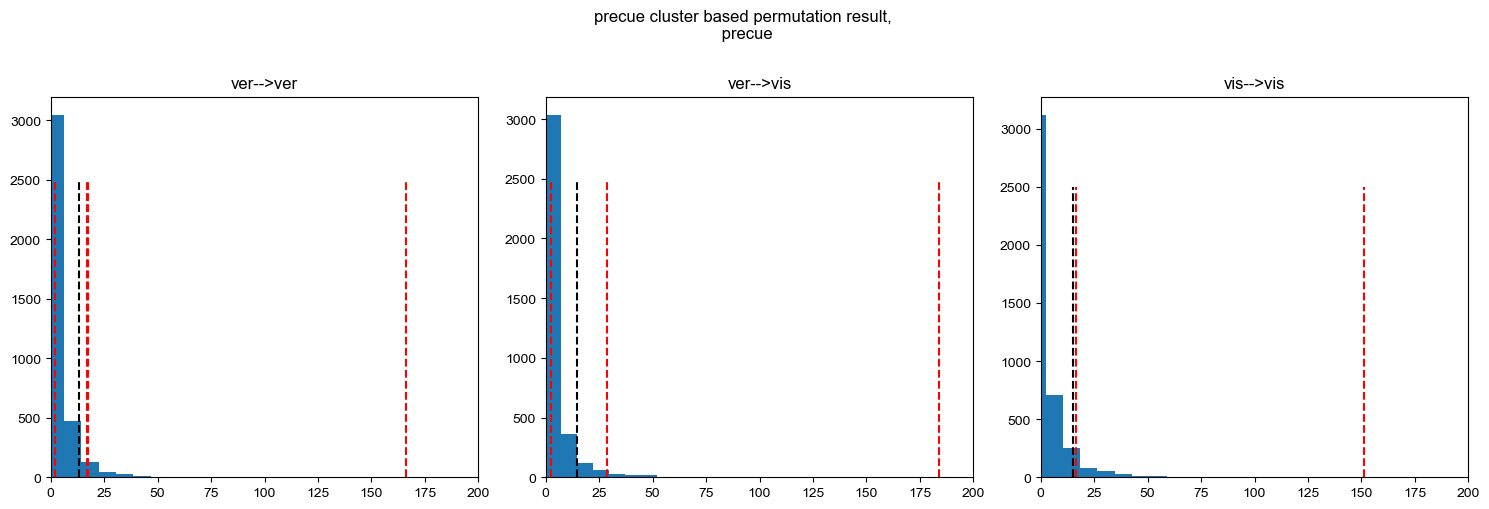

In [426]:
fs(15,5)
fig,ax = plt.subplots(ncols = 3)
dataN = 60
dataThis = last_layer_precue[last_layer_precue.comparison == 'verbalverbal']
realT,realP = oneSampTTest(dataThis.iloc[:,:dataN],popmean=0,axis=0, nan_policy='propagate')
consGroups_precue_verver = consecutive(np.where(realP <= 0.05)[0], stepsize=1,
                        findSame = False)
fsum_precue_verver = [realT[i].sum() for i in consGroups_precue_verver]
pValue_precue_verver = [sum(fCluster_precue[0] > i)/perms for i in fsum_precue_verver]
print(f'verver has {len(fsum_precue_verver)} clusters, clusters with p value {pValue_precue_verver}, the clusters are \n {consGroups_precue_verver}',)

ax[0].hist(fCluster_precue[0],bins = 20)
ax[0].vlines([fsum_precue_verver],0,perms/2,linestyles = 'dashed',color ='r')
ax[0].vlines(np.percentile(fCluster_precue[0],95),0,perms/2,linestyles = 'dashed',color ='black')
ax[0].set_xlim(0,200)

dataThis = last_layer_precue[last_layer_precue.comparison == 'verbalvisual']
realT,realP = oneSampTTest(dataThis.iloc[:,:dataN],popmean=0,axis=0, nan_policy='propagate')
consGroups_precue_vervis = consecutive(np.where(realP <= 0.05)[0], stepsize=1,
                        findSame = False)
fsum_precue_vervis = [realT[i].sum() for i in consGroups_precue_vervis]
pValue_precue_vervis = [sum(fCluster_precue[1] > i)/perms for i in fsum_precue_vervis]
print(f'vervis has {len(fsum_precue_vervis)}clusters, clusters with p value {pValue_precue_vervis}, the clusters are \n {consGroups_precue_vervis}',)

ax[1].hist(fCluster_precue[1],bins = 20)
ax[1].vlines([fsum_precue_vervis],0,perms/2,linestyles = 'dashed',color ='r')
ax[1].vlines(np.percentile(fCluster_precue[1],95),0,perms/2,linestyles = 'dashed',color ='black')
ax[1].set_xlim(0,200)


dataThis = last_layer_precue[last_layer_precue.comparison == 'visualvisual']
realT,realP = oneSampTTest(dataThis.iloc[:,:dataN],popmean=0,axis=0, nan_policy='propagate')
consGroups_precue_visvis = consecutive(np.where(realP <= 0.05)[0], stepsize=1,
                        findSame = False)
fsum_precue_visvis = [realT[i].sum() for i in consGroups_precue_visvis]
pValue_precue_visvis = [sum(fCluster_precue[2] > i)/perms for i in fsum_precue_visvis]
print(f'visvis has {len(fsum_precue_visvis)}clusters, clusters with p value {pValue_precue_visvis}, the clusters are \n {consGroups_precue_visvis}',)

ax[2].hist(fCluster_precue[2],bins = 20)
ax[2].vlines([fsum_precue_visvis],0,perms/2,linestyles = 'dashed',color ='r')
ax[2].vlines(np.percentile(fCluster_precue[2],95),0,perms/2,linestyles = 'dashed',color ='black')
ax[2].set_xlim(0,200)


ax[0].set_title('ver-->ver')
ax[1].set_title('ver-->vis')
ax[2].set_title('vis-->vis')

plt.suptitle('precue cluster based permutation result, \n precue', y = 1.01)
plt.tight_layout()

In [453]:
def report_significant_clusters(data, comparison, fCluster, perms, dataN, label):
    dataThis = data[data.comparison == comparison]
    realT, realP = oneSampTTest(dataThis.iloc[:, :dataN], popmean=0, axis=0, nan_policy='propagate')

    consGroups = consecutive(np.where(realP <= 0.05)[0], stepsize=1, findSame=False)
    fsum = [realT[i].sum() for i in consGroups]
    pValue = [sum(fCluster[0] > i) / perms for i in fsum]

    significance = np.array(consGroups, dtype=object)[np.where(np.array(pValue) < 0.05)[0]]
    sig_formatted = [ (i[0]/10 - 0.5, i[-1]/10 + 0.1 - 0.5)for  i in significance]  # correct for the downsampled data, also correct for the first 500ms iti
    print(f'significant clusters for {label} (against 0) :')
    for i in significance:
        print(f"{i[0]/10 - 0.5 :.2f} to {i[-1]/10 + 0.1 - 0.5:.2f} seconds")  # correct for the downsampled data, also correct for the first 500ms iti
    print('\n')

    return sig_formatted


significance_precue_verver = report_significant_clusters(
    last_layer_precue, 'verbalverbal', fCluster_precue, perms, dataN, 'semantic-semantic')
significance_precue_verviz = report_significant_clusters(
    last_layer_precue, 'verbalvisual', fCluster_precue, perms, dataN, 'semantic-visual')
significance_precue_vizviz = report_significant_clusters(
    last_layer_precue, 'visualvisual', fCluster_precue, perms, dataN, 'visual-visual')


significant clusters for semantic-semantic (against 0) :
1.20 to 3.00 seconds
3.80 to 4.50 seconds
4.60 to 5.30 seconds


significant clusters for semantic-visual (against 0) :
0.90 to 3.10 seconds
4.40 to 5.50 seconds


significant clusters for visual-visual (against 0) :
1.20 to 3.10 seconds
4.90 to 5.50 seconds




In [454]:

significance_retrocue_verver = report_significant_clusters(
    last_layer_retrocue, 'verbalverbal', fCluster_retrocue, perms, dataN, 'semantic-semantic')
significance_retrocue_verviz = report_significant_clusters(
    last_layer_retrocue, 'verbalvisual', fCluster_retrocue, perms, dataN, 'semantic-visual')
significance_retrocue_vizviz = report_significant_clusters(
    last_layer_retrocue, 'visualvisual', fCluster_retrocue, perms, dataN, 'visual-visual')


significant clusters for semantic-semantic (against 0) :
0.20 to 1.70 seconds


significant clusters for semantic-visual (against 0) :
0.20 to 1.80 seconds


significant clusters for visual-visual (against 0) :
0.20 to 1.80 seconds
4.80 to 5.50 seconds




## adding permutation results to the plot

In [416]:
corrDf_precue = dsCorr_precue_last_layer.copy()
corrDf_retrocue = dsCorr_retrocue_last_layer.copy()

In [417]:
corrDfMean_precue = corrDf_precue.groupby(['current','target']).mean(numeric_only=True)
corrDfsem_precue = corrDf_precue.groupby(['current','target']).sem(numeric_only=True)

corrDfMean_retrocue = corrDf_retrocue.groupby(['current','target']).mean(numeric_only=True)
corrDfsem_retrocue = corrDf_retrocue.groupby(['current','target']).sem(numeric_only=True)


In [418]:
labelArr = ['ver --> ver','ver --> vis','vis --> vis']
cList = ['#9d76af',"#999999",'#66a99f']
dataN = 600

In [455]:
significance_precue_verver

[(1.2, 3.0), (3.8, 4.5), (4.6, 5.3)]

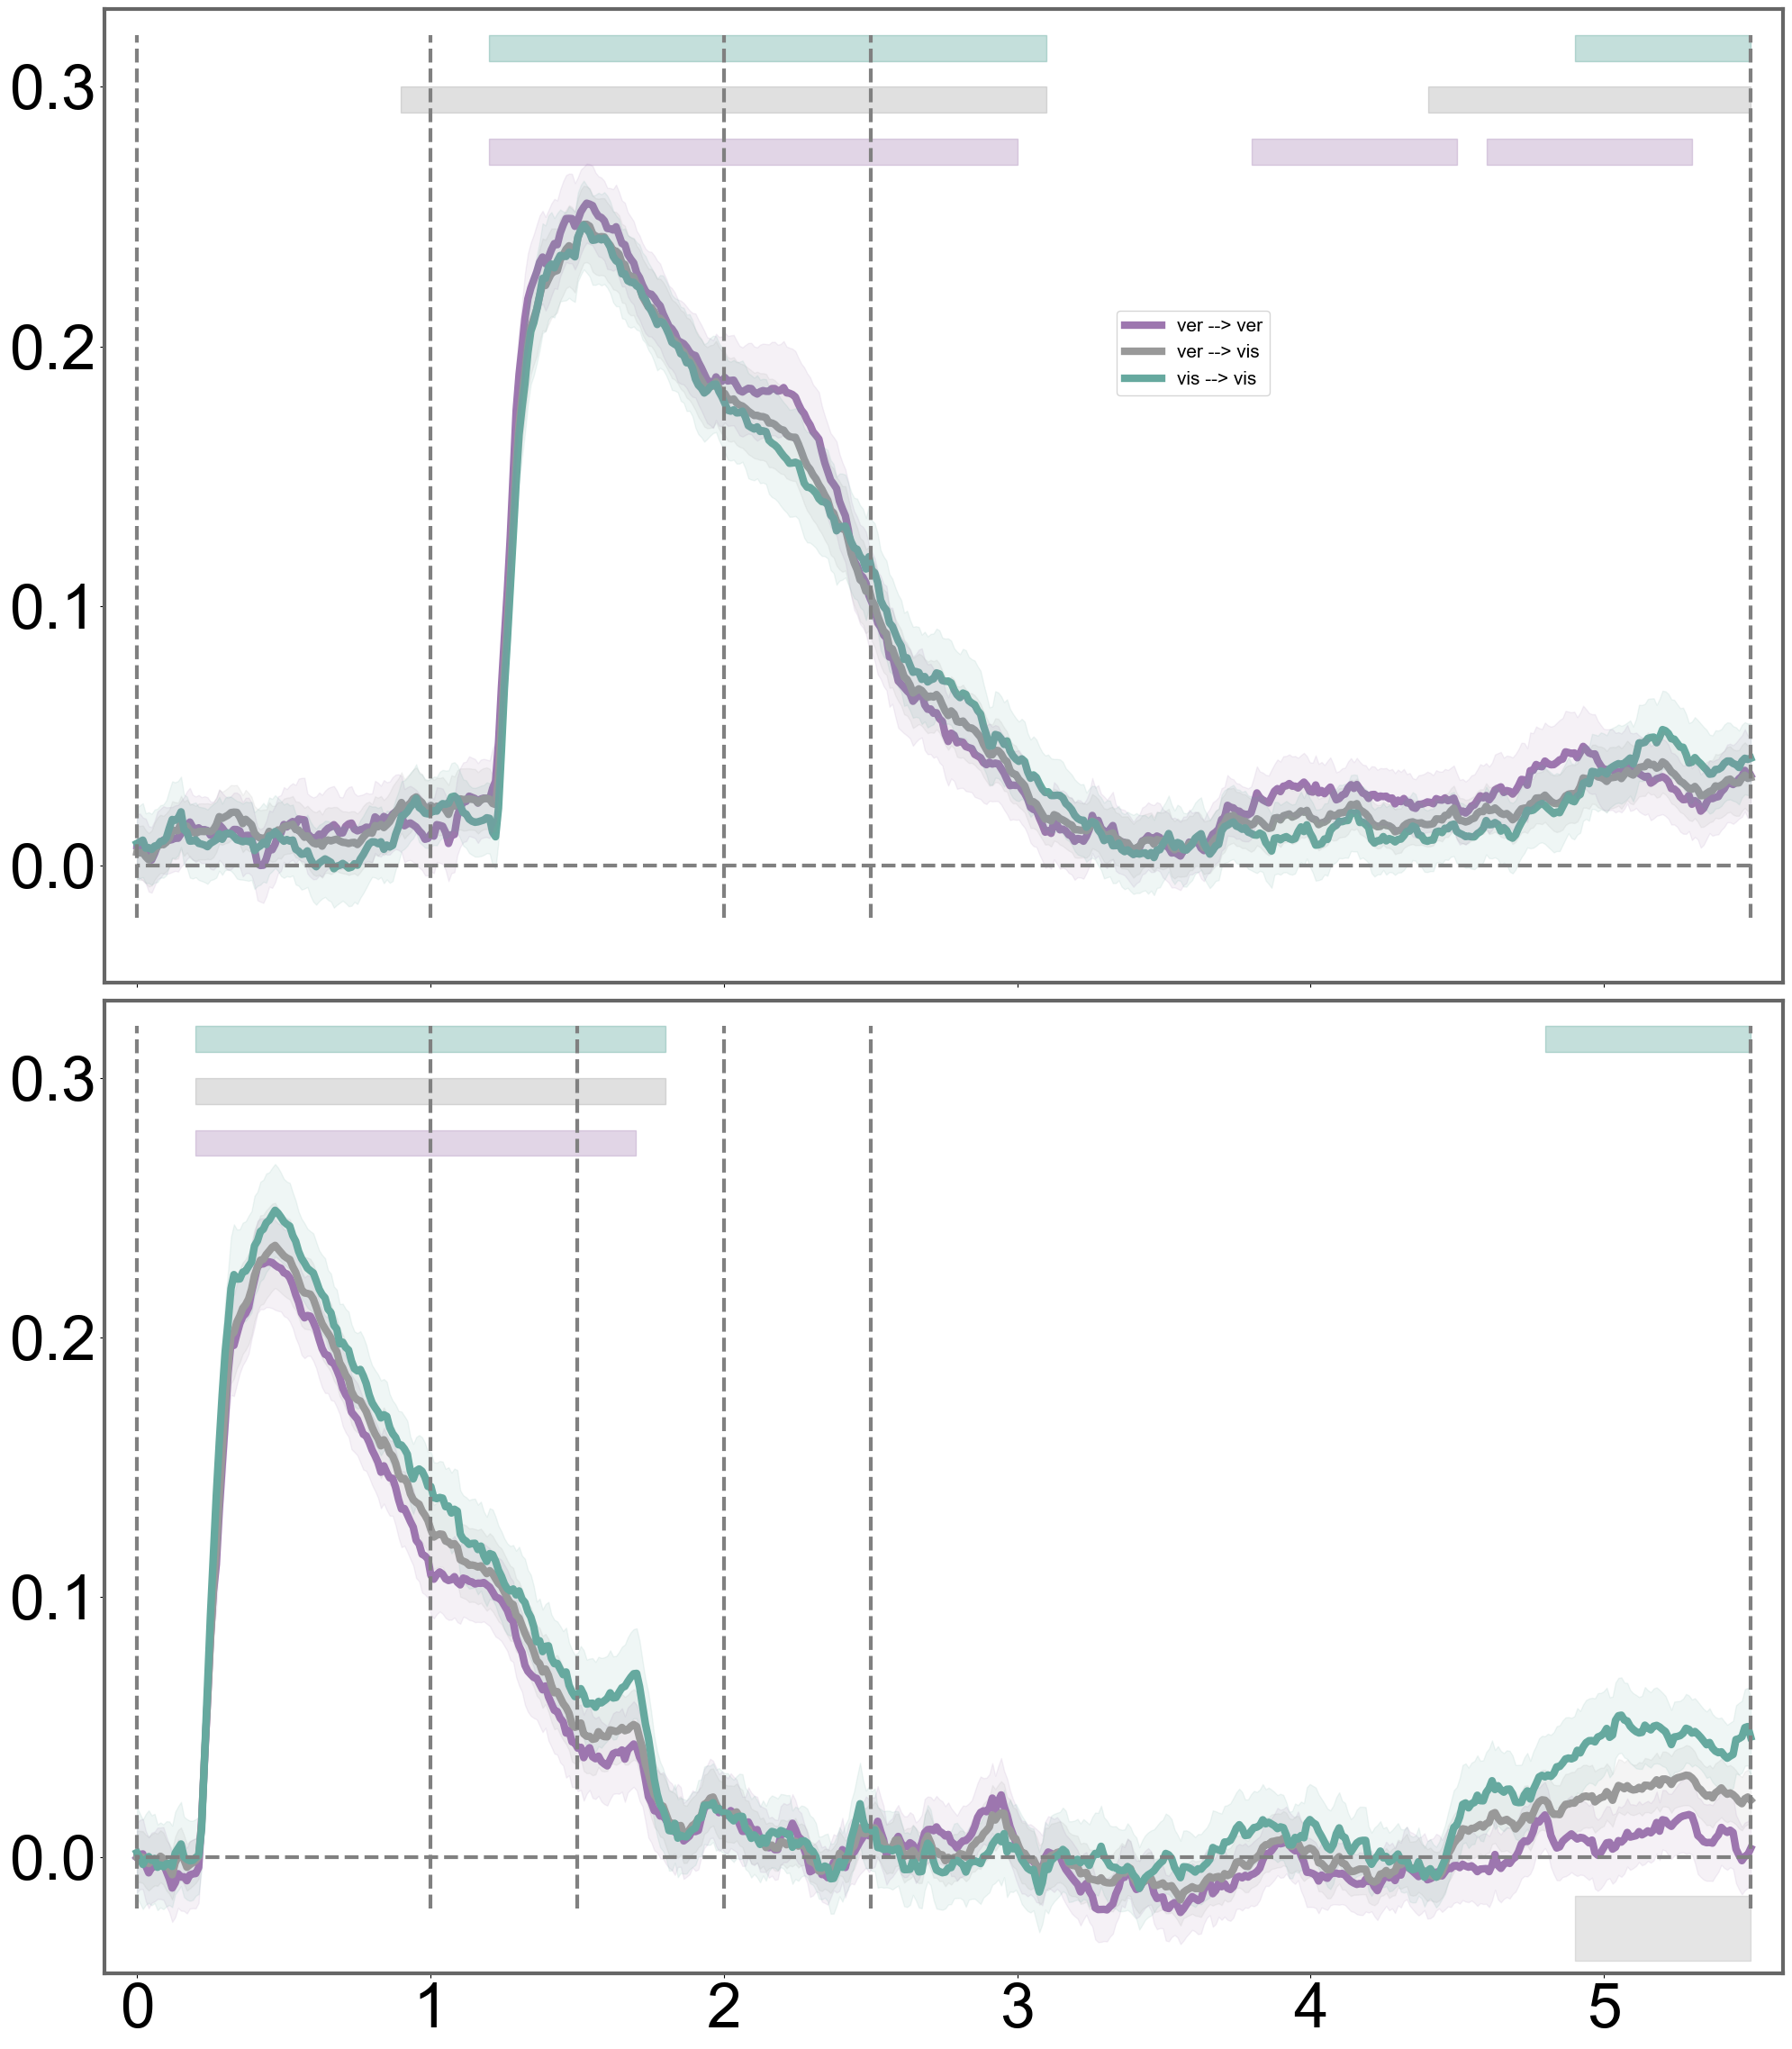

In [ ]:
dataN = 600
fig,ax = plt.subplots(nrows = 2,figsize = (20,23),sharex=True,sharey=True)
xAxis = np.linspace(0,5.5,dataN-50)



[ax[0].fill_between(i,0.26+0.01,0.27+0.01,color = "#9d76af",alpha = 0.3) for i in significance_precue_verver]
[ax[0].fill_between(i,0.28+0.01,0.29+0.01,color = '#666666',alpha = 0.2) for i in significance_precue_verviz]
[ax[0].fill_between(i,0.30+0.01,0.31+0.01,color = "#3d9688",alpha = 0.3) for i in significance_precue_vizviz]

[ax[1].fill_between(i,0.26+0.01,0.27+0.01,color = "#9d76af",alpha = 0.3) for i in significance_retrocue_verver]
[ax[1].fill_between(i,0.28+0.01,0.29+0.01,color = '#666666',alpha = 0.2) for i in significance_retrocue_verviz]
[ax[1].fill_between(i,0.30+0.01,0.31+0.01,color = "#3d9688",alpha = 0.3) for i in significance_retrocue_vizviz]

ax[1].fill_between([4.9,5.5],-0.04,-0.015,color = 'grey',alpha = 0.2,zorder = 1)


[ax[1].plot(xAxis,corrDfMean_retrocue.iloc[i,50:dataN].values,
            label = labelArr[i],c = cList[i],linewidth = 6) for i in [0,1,2]]

[ax[0].plot(xAxis,corrDfMean_precue.iloc[i,50:dataN].values,
            label = labelArr[i],c = cList[i],linewidth = 6,zorder = 0) for i in [0,1,2]] #range(3)

[ax[1].fill_between(xAxis,corrDfMean_retrocue.iloc[i,50:dataN].values + corrDfsem_retrocue.iloc[i,50:dataN].values,
                    corrDfMean_retrocue.iloc[i,50:dataN].values - corrDfsem_retrocue.iloc[i,50:dataN].values,
                    alpha = 0.1,color = cList[i]) for i in [0,1,2]]

[ax[0].fill_between(xAxis,corrDfMean_precue.iloc[i,50:dataN].values + corrDfsem_precue.iloc[i,50:dataN].values,
                    corrDfMean_precue.iloc[i,50:dataN].values - corrDfsem_precue.iloc[i,50:dataN].values,
                    alpha = 0.1,color = cList[i]) for i in [0,1,2]]



ax[0].vlines(np.array(precueT) - 0.5,-0.02,0.32,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].vlines(np.array(retrocueT) - 0.5,-0.02,0.32,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[0].hlines(0,5.5,0,colors = 'grey',linestyles = 'dashed',linewidth = 3)
ax[1].hlines(0,5.5,0,colors = 'grey',linestyles = 'dashed',linewidth = 3)

ax[0].legend(fontsize = 15,bbox_to_anchor = (0.7,0.7))
ax[0].set_title('')
ax[1].set_title('')
plt.suptitle('',fontsize = 15)

ax[0].yaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax[1].yaxis.set_major_locator(ticker.MultipleLocator(0.1))

ax[1].tick_params(labelsize=50)
ax[0].tick_params(labelsize=50)
ax[0].set_ylim(-0.045,0.33)

style_spines(ax[0])
style_spines(ax[1])
ax[0]. margins(x=0.02)

fig.tight_layout()